In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# Load dataset
df = pd.read_csv('train.csv', encoding='latin-1')

# Shape
print("Shape:", df.shape)

# Column Names
print("\nColumn Names:\n", df.columns.tolist())

# Data Types
print("\nData Types:\n", df.dtypes)

# Null Values
print("\nNull Values:\n", df.isnull().sum())



Shape: (9800, 18)

Column Names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data Types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Null Values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region 

## Step 1 - Initial Inspection
- Dataset has 9800 rows and 18 columns
- Only Postal Code has 11 missing values which is not important
- Sales column is float type and ready for analysis
- Order Date is object type and needs to be converted to datetime

In [26]:
# Mean, Median, Mode, Standard Deviation
print("=== MEAN ===")
print(df[['Sales']].mean())

print("\n=== MEDIAN ===")
print(df[['Sales']].median())

print("\n=== MODE ===")
print(df[['Sales']].mode().iloc[0])

print("\n=== STANDARD DEVIATION ===")
print(df[['Sales']].std())

print("\n=== FULL SUMMARY ===")
print(df.describe())

=== MEAN ===
Sales    230.769059
dtype: float64

=== MEDIAN ===
Sales    54.49
dtype: float64

=== MODE ===
Sales    12.96
Name: 0, dtype: float64

=== STANDARD DEVIATION ===
Sales    626.651875
dtype: float64

=== FULL SUMMARY ===
            Row ID   Postal Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%    4900.500000  58103.000000     54.490000
75%    7350.250000  90008.000000    210.605000
max    9800.000000  99301.000000  22638.480000


## Step 2 - Descriptive Statistics
- Average (Mean) Sales per order is around 230
- Median Sales is around 54 which means most orders are small
- Standard Deviation is high meaning sales values vary a lot
- There are some very high value orders pulling the mean up

In [27]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.to_period('M')
df['Quarter'] = df['Order Date'].dt.to_period('Q')
print("Date column fixed!")

Date column fixed!


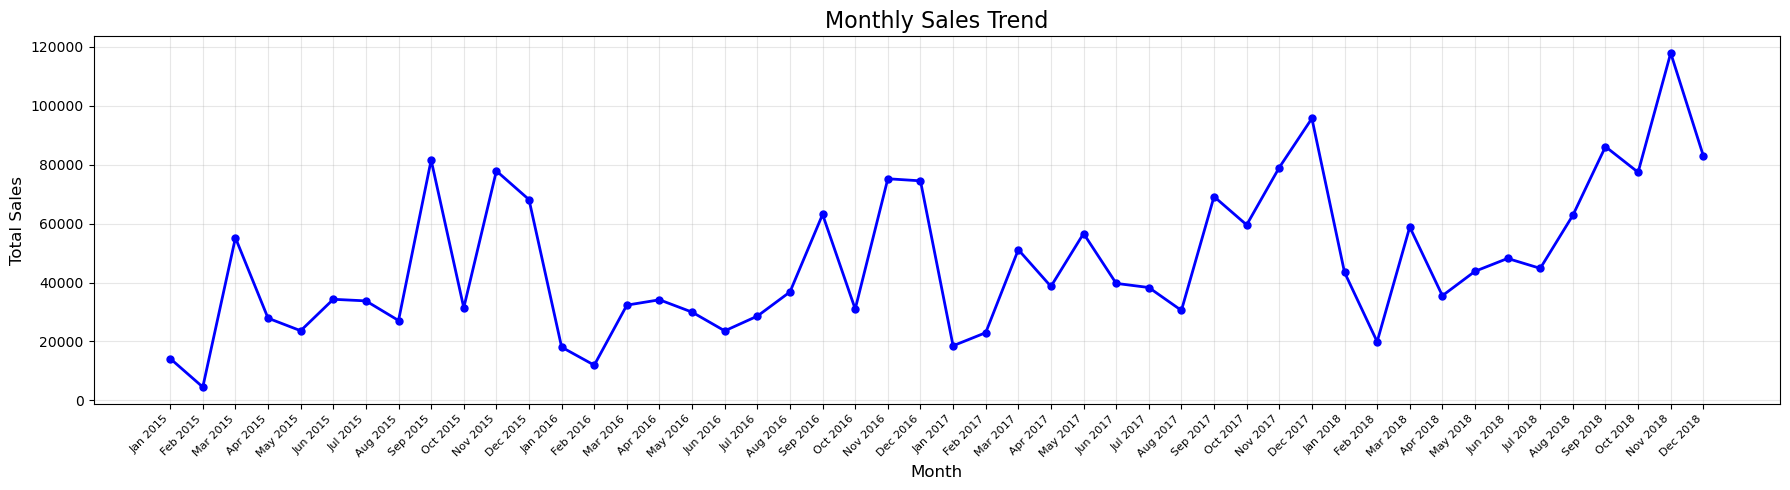

In [32]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.strftime('%b %Y')

plt.figure(figsize=(18,5))
plt.plot(monthly_sales.values, color='blue', marker='o', markersize=5, linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(range(len(monthly_sales)), monthly_sales.index, rotation=45, ha='right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

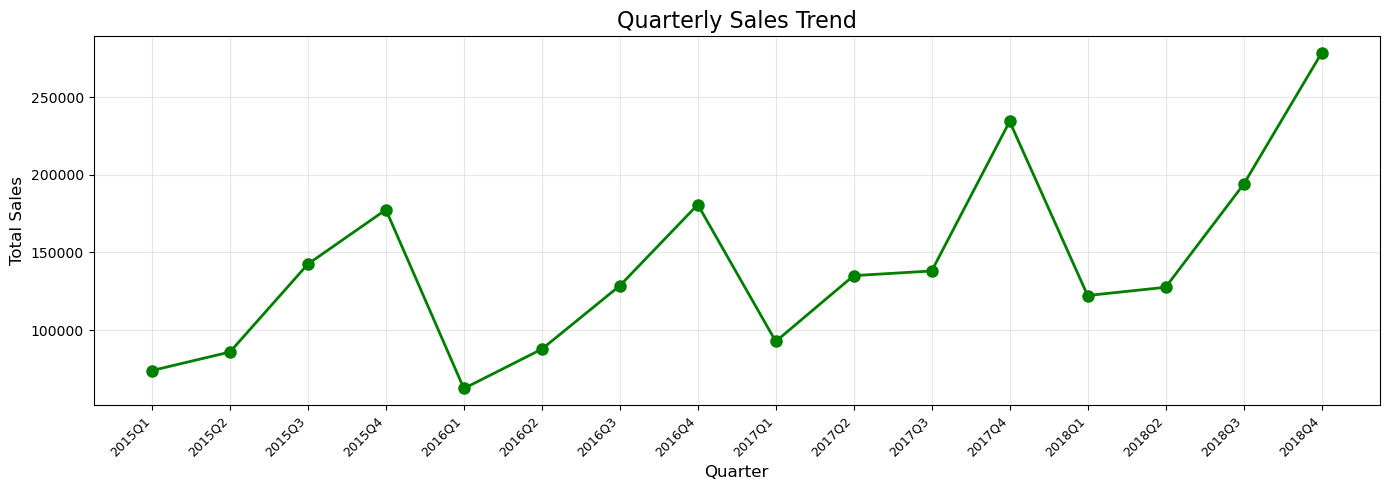

In [33]:
quarterly_sales = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum()
quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(14,5))
plt.plot(quarterly_sales.values, color='green', marker='o', markersize=8, linewidth=2)
plt.title('Quarterly Sales Trend', fontsize=16)
plt.xlabel('Quarter', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(range(len(quarterly_sales)), quarterly_sales.index, rotation=45, ha='right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 3 - Time Series Analysis
- Monthly sales show an overall upward trend over the years
- Sales consistently peak in November and December every year
- Sales dip in January and February every year
- Quarterly analysis confirms Q4 is always the strongest quarter
- Q1 is consistently the weakest quarter every year

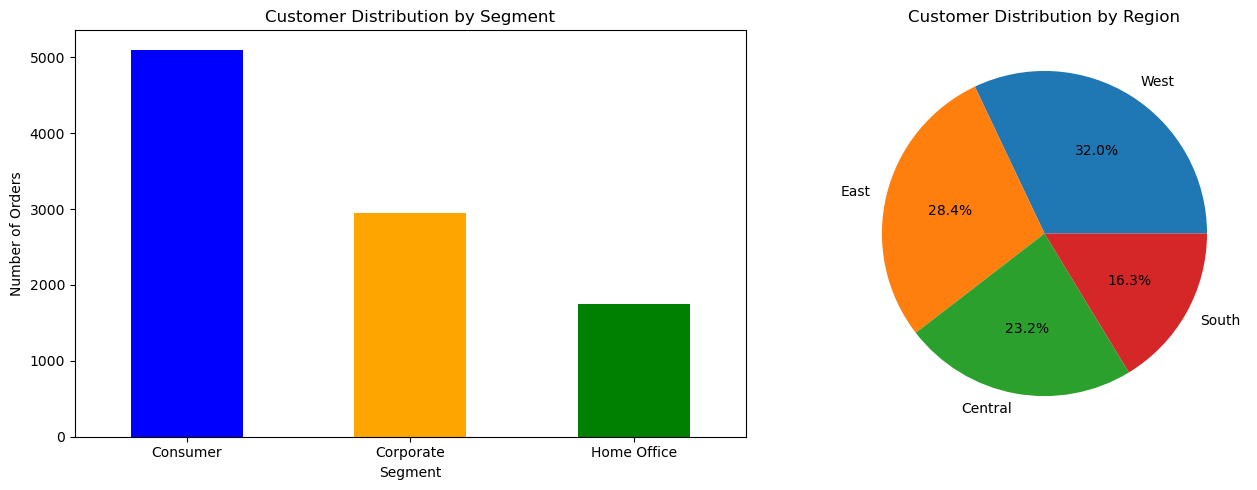

In [34]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
segment_counts = df['Segment'].value_counts()
segment_counts.plot(kind='bar', color=['blue','orange','green'])
plt.title('Customer Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.subplot(1,2,2)
region_counts = df['Region'].value_counts()
region_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Customer Distribution by Region')
plt.ylabel('')

plt.tight_layout()
plt.show()

## Step 4 - Customer Demographics
- Consumer segment has the highest number of orders
- Corporate segment is second largest
- Home Office segment has the least orders
- West region has the highest customer distribution
- South region has the lowest customer distribution

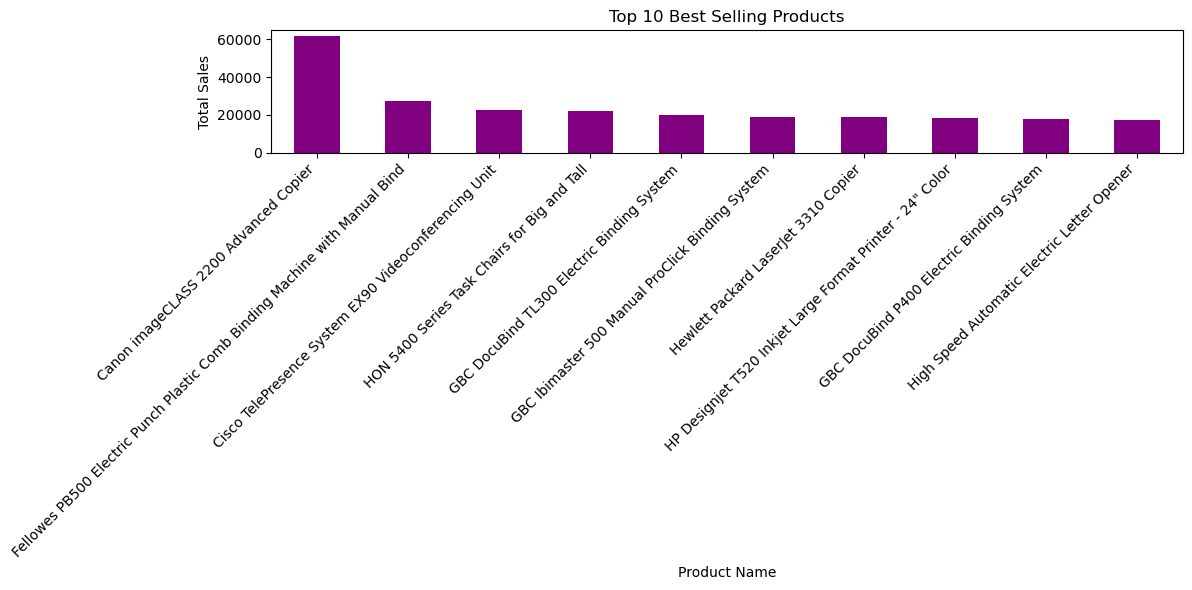

In [35]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
plt.figure(figsize=(12,6))
top_products.plot(kind='bar', color='purple')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Product Name')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

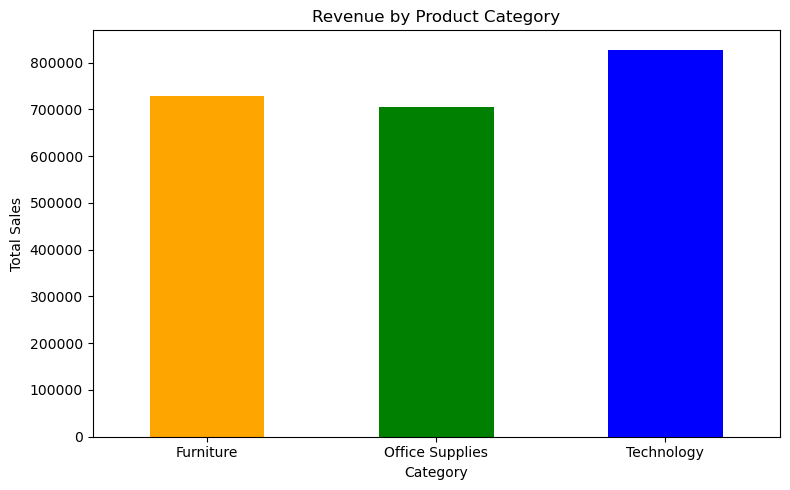

In [36]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['orange','green','blue'])
plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 5 - Product Analysis
- Technology category generates the highest revenue
- Furniture comes second followed by Office Supplies
- Canon image CLASS is the top selling product
- Most top 10 products belong to Technology category
- These top products should always be kept in stock

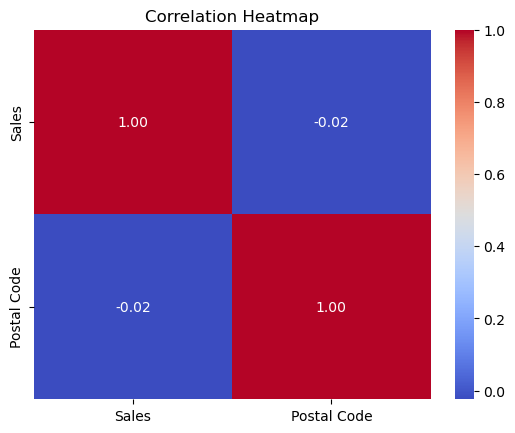

In [40]:
sns.heatmap(df[['Sales','Postal Code']].corr(), 
            annot=True, 
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Step 6 - Correlation Heatmap
- Sales and Postal Code show very little correlation
- Location alone does not significantly impact sales amount
- Other factors like category and segment play a bigger role

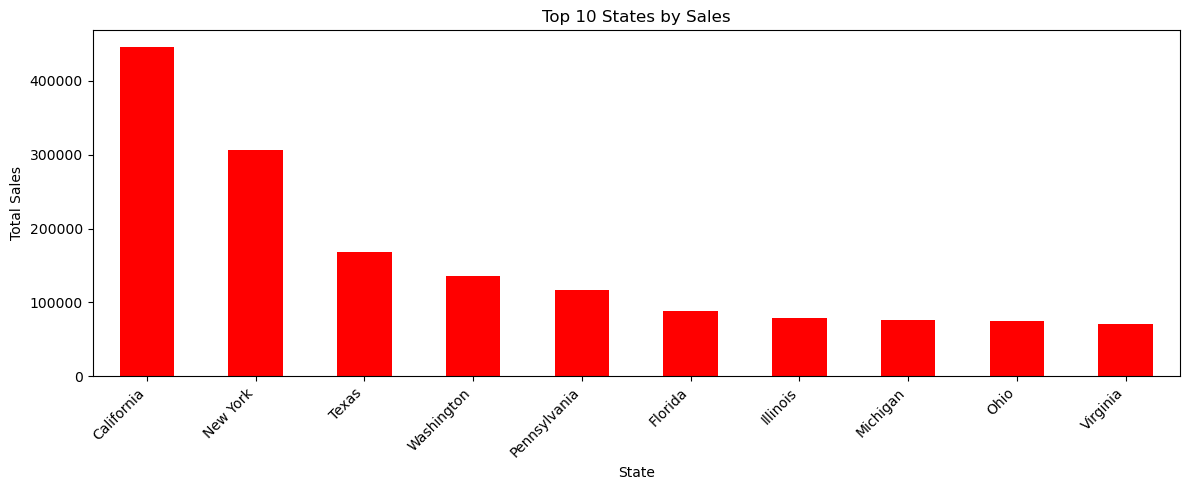

In [38]:
top_states = df.groupby('State')['Sales'].sum().nlargest(10)
plt.figure(figsize=(12,5))
top_states.plot(kind='bar', color='red')
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 7 - Additional Insight - Top 10 States
- California has the highest sales among all states
- New York comes second followed by Texas
- These 3 states alone contribute a large portion of total sales
- States outside top 10 need special marketing attention

## Conclusion - Business Recommendations

Based on the EDA analysis of the Superstore Sales dataset 
(9800 rows, 18 columns), here are 3 key actionable recommendations:

1. **Focus on Technology Category**
   - Technology generates the highest revenue among all categories
   - Expanding Technology product range will significantly boost overall sales
   - Top selling products like Canon imageCLASS should always be in stock

2. **Target South Region and Weak States**
   - South region has the lowest sales and customer distribution
   - States outside top 10 need targeted marketing campaigns
   - Special discounts and promotions in these areas can improve sales

3. **Leverage Holiday Season (Q4)**
   - Sales consistently peak in Q4 (October - December) every year
   - Stock up inventory before Q4 and run special holiday promotions
   - Introduce early bird offers in Q3 to build momentum into Q4